In [1]:
import csv

import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# 各パス指定

In [2]:
import os
import glob
import numpy as np

# Load all CSV files from Words-Dataset folder that are not _sequence
csv_files = sorted(glob.glob('Words-Dataset/???.csv'))
data_frames = []
labels = []
for csv_file in csv_files:
    data = np.loadtxt(csv_file, delimiter=',', dtype='float32')
    data_frames.append(data)
    # Use the first column as label
    labels.extend(data[:, 0].astype(int))

if data_frames:
    dataset_array = np.vstack(data_frames)
    dataset_array[:, 0] = labels  # set the label column
    # Save to file
    # np.savetxt('model/keypoint_classifier/keypoint.csv', dataset_array, delimiter=',')
    X_dataset = dataset_array[:, 1:81]  # assuming 80 features
    y_dataset = dataset_array[:, 0].astype('int32')
else:
    raise ValueError("No data found in Words-Dataset folder")

model_save_path = 'model/keypoint_classifier/keypoint_classifier.keras'

ValueError: No data found in Words-Dataset folder

In [ ]:
y_dataset -= 1  # Convert from 1-based to 0-based indexing for TensorFlow

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_dataset, y_dataset, train_size=0.75, random_state=RANDOM_SEED)

# 分類数設定

In [ ]:
# Load labels to determine number of classes
with open('Word-Label/keypoint_classifier_label.csv', encoding='utf-8-sig') as f:
    keypoint_classifier_labels = csv.reader(f)
    keypoint_classifier_labels = [row[0] for row in keypoint_classifier_labels]
NUM_CLASSES = len(keypoint_classifier_labels)
print(f"Number of classes: {NUM_CLASSES}")
print(f"Labels: {keypoint_classifier_labels}")

Number of classes: 5
Labels: ['---', '十', '---', '---', '---']


# モデル構築

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input((80,)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
]) # 6 layers

In [ ]:
model.summary()  # tf.keras.utils.plot_model(model, show_shapes=True)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 128)               10368     
                                                                 
 batch_normalization_6 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_10 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_7 (Bat  (None, 64)                256       
 chNormalization)                                                
                                                                 
 dropout_7 (Dropout)         (None, 64)               

In [ ]:
# モデルチェックポイントのコールバック
cp_callback = tf.keras.callbacks.ModelCheckpoint(
    model_save_path, verbose=1, save_weights_only=False)
# 早期打ち切り用コールバック
es_callback = tf.keras.callbacks.EarlyStopping(patience=20, verbose=1)

In [ ]:
# モデルコンパイル
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# モデル訓練

In [ ]:
model.fit(
    X_train,
    y_train,
    epochs=2000,
    batch_size=128,
    validation_data=(X_test, y_test),
    callbacks=[cp_callback, es_callback]
)

Epoch 1/2000
1/2 [==============>...............] - ETA: 0s - loss: 2.4292 - accuracy: 0.1484
Epoch 1: saving model to model/keypoint_classifier/keypoint_classifier.keras
2/2 [==============================] - 0s 79ms/step - loss: 2.3747 - accuracy: 0.1365 - val_loss: 1.5952 - val_accuracy: 0.0000e+00
Epoch 2/2000
1/2 [==============>...............] - ETA: 0s - loss: 2.2025 - accuracy: 0.2422
Epoch 2: saving model to model/keypoint_classifier/keypoint_classifier.keras
2/2 [==============================] - 0s 18ms/step - loss: 2.2591 - accuracy: 0.2450 - val_loss: 1.5640 - val_accuracy: 0.0000e+00
Epoch 3/2000
1/2 [==============>...............] - ETA: 0s - loss: 2.0577 - accuracy: 0.2656
Epoch 3: saving model to model/keypoint_classifier/keypoint_classifier.keras
2/2 [==============================] - 0s 18ms/step - loss: 2.0307 - accuracy: 0.2570 - val_loss: 1.5310 - val_accuracy: 0.0000e+00
Epoch 4/2000
1/2 [==============>...............] - ETA: 0s - loss: 2.0592 - accuracy: 0.24

In [ ]:
# モデル評価
val_loss, val_acc = model.evaluate(X_test, y_test, batch_size=128)

1/1 [==============================] - 0s 10ms/step - loss: 0.0206 - accuracy: 1.0000


In [ ]:
# 保存したモデルのロード
model = tf.keras.models.load_model(model_save_path)

In [ ]:
# 推論テスト
predict_result = model.predict(np.array([X_test[0]]))
print(np.squeeze(predict_result))
print(np.argmax(np.squeeze(predict_result)))

1/1 [==============================] - 0s 29ms/step
[0.00216671 0.98993975 0.0024986  0.00279696 0.00259798]
1


# 混同行列

3/3 [==============================] - 0s 1ms/step


/Users/ronald8931/Desktop/hands/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


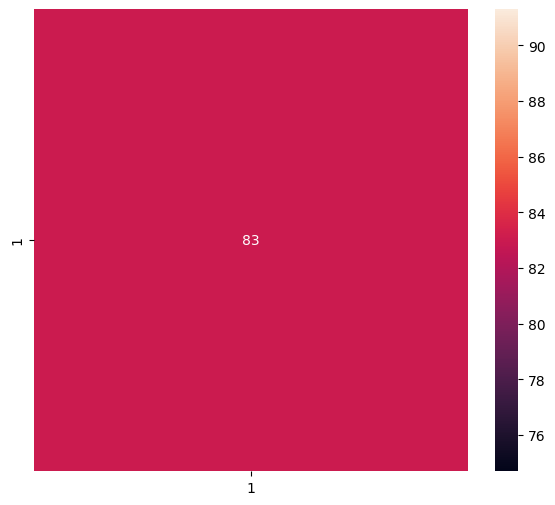

Classification Report
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        83

    accuracy                           1.00        83
   macro avg       1.00      1.00      1.00        83
weighted avg       1.00      1.00      1.00        83



In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def print_confusion_matrix(y_true, y_pred, report=True):
    labels = sorted(list(set(y_true)))
    cmx_data = confusion_matrix(y_true, y_pred, labels=labels)
    
    df_cmx = pd.DataFrame(cmx_data, index=labels, columns=labels)
 
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(df_cmx, annot=True, fmt='g' ,square=False)
    ax.set_ylim(len(set(y_true)), 0)
    plt.show()
    
    if report:
        print('Classification Report')
        print(classification_report(y_test, y_pred))

Y_pred = model.predict(X_test)
y_pred = np.argmax(Y_pred, axis=1)

print_confusion_matrix(y_test, y_pred)

# Tensorflow-Lite用のモデルへ変換

In [ ]:
# 推論専用のモデルとして保存
model.save(model_save_path)

In [ ]:
# モデルを変換(量子化)
tflite_save_path = 'model/keypoint_classifier/keypoint_classifier.tflite'

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_quantized_model = converter.convert()

open(tflite_save_path, 'wb').write(tflite_quantized_model)

INFO:tensorflow:Assets written to: /var/folders/wt/bj47w0pj3h529wfvv7wn357w0000gn/T/tmpleboj2lk/assets


INFO:tensorflow:Assets written to: /var/folders/wt/bj47w0pj3h529wfvv7wn357w0000gn/T/tmpleboj2lk/assets
2025-12-26 00:25:33.516315: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2025-12-26 00:25:33.516328: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2025-12-26 00:25:33.516440: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /var/folders/wt/bj47w0pj3h529wfvv7wn357w0000gn/T/tmpleboj2lk
2025-12-26 00:25:33.517275: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2025-12-26 00:25:33.517281: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /var/folders/wt/bj47w0pj3h529wfvv7wn357w0000gn/T/tmpleboj2lk
2025-12-26 00:25:33.519386: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2025-12-26 00:25:33.536450: I tensorflow/cc/saved_model/loader.cc:217] Running initialization

23312

# 推論テスト

In [ ]:
interpreter = tf.lite.Interpreter(model_path=tflite_save_path)
interpreter.allocate_tensors()

In [ ]:
# 入出力テンソルを取得
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

In [ ]:
interpreter.set_tensor(input_details[0]['index'], np.array([X_test[0]]))

In [ ]:
%%time
# 推論実施
interpreter.invoke()
tflite_results = interpreter.get_tensor(output_details[0]['index'])

CPU times: user 51 μs, sys: 18 μs, total: 69 μs
Wall time: 54.8 μs


In [ ]:
print(np.squeeze(tflite_results))
print(np.argmax(np.squeeze(tflite_results)))

[0.00216845 0.98965573 0.00254093 0.00291893 0.002716  ]
1
